# Cell 1: 라이브러리 임포트 및 설정

In [ ]:
# %% [Cell 1] - 라이브러리 임포트 및 기본 설정

import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from skorch import NeuralNetClassifier

from sklearn.model_selection import (train_test_split, RepeatedStratifiedKFold,
                                     cross_val_score, learning_curve, StratifiedKFold)
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score, f1_score, classification_report,
                             confusion_matrix, precision_recall_curve)
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

import optuna

%matplotlib inline
sns.set(style="whitegrid")

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS device is available. Using MPS!")
else:
    device = torch.device("cpu")
    print("MPS device is not available. Using CPU.")

import warnings
warnings.filterwarnings("ignore")


MPS device is available. Using MPS!


# Cell 2: 데이터 로딩 및 기본 전처리

In [ ]:
# %% [Cell 2] - 데이터 로딩 & 기본 전처리

train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

# 테스트 데이터의 ID 보존
test_ids = test_df['ID'].copy()

# ID 컬럼 제거
train_df.drop(columns=['ID'], inplace=True)
test_df.drop(columns=['ID'], inplace=True)

target_col = "임신 성공 여부"  # 실제 타겟 열 이름

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# fillna(-1)
train_df.fillna(-1, inplace=True)
test_df.fillna(-1, inplace=True)

print("Train -1 count:\n", (train_df==-1).sum())
print("Test  -1 count:\n", (test_df==-1).sum())


Train shape: (256351, 68)
Test shape : (90067, 67)
Train -1 count:
 시술 시기 코드                      0
시술 당시 나이                      0
임신 시도 또는 마지막 임신 경과 연수    246981
시술 유형                         0
특정 시술 유형                      2
                          ...  
난자 해동 경과일                254915
난자 혼합 경과일                 53735
배아 이식 경과일                 43566
배아 해동 경과일                215982
임신 성공 여부                      0
Length: 68, dtype: int64
Test  -1 count:
 시술 시기 코드                     0
시술 당시 나이                     0
임신 시도 또는 마지막 임신 경과 연수    86770
시술 유형                        0
특정 시술 유형                     0
                         ...  
난자 채취 경과일                19949
난자 해동 경과일                89575
난자 혼합 경과일                18579
배아 이식 경과일                15246
배아 해동 경과일                76117
Length: 67, dtype: int64


# Cell 3: 도메인 기반 + 기본 Feature Engineering 및 결측치 처리

In [ ]:
# %% [Cell 3] - 도메인 기반 + 기존 Feature Engineering

count_cols = [
    "총 시술 횟수","IVF 시술 횟수","DI 시술 횟수",
    "총 임신 횟수","IVF 임신 횟수","DI 임신 횟수",
    "총 출산 횟수","IVF 출산 횟수","DI 출산 횟수"
]
for c in count_cols:
    if c in train_df.columns:
        train_df[c] = pd.to_numeric(train_df[c].astype(str).str.replace(r"[^\d]", "", regex=True), errors='coerce')
    if c in test_df.columns:
        test_df[c]  = pd.to_numeric(test_df[c].astype(str).str.replace(r"[^\d]", "", regex=True), errors='coerce')

# (예시) "시술 유형" 원본 복사
if "시술 유형" in train_df.columns:
    train_df["시술 유형_원본"] = train_df["시술 유형"].copy()
if "시술 유형" in test_df.columns:
    test_df["시술 유형_원본"]  = test_df["시술 유형"].copy()

# (예시) 임신 시도 대비 성공률
if ("총 시술 횟수" in train_df.columns) and ("총 임신 횟수" in train_df.columns):
    train_df["임신 시도 대비 성공률"] = (train_df["총 임신 횟수"]+1)/(train_df["총 시술 횟수"]+1)
    test_df["임신 시도 대비 성공률"]  = (test_df["총 임신 횟수"]+1)/(test_df["총 시술 횟수"]+1)

# (예시) 연령대별 평균 임신 성공률
if ("시술 당시 나이" in train_df.columns) and (target_col in train_df.columns):
    age_success_rate = train_df.groupby("시술 당시 나이")[target_col].mean()
    train_df["연령대 평균 임신 성공률"] = train_df["시술 당시 나이"].map(age_success_rate)
    if "시술 당시 나이" in test_df.columns:
        test_df["연령대 평균 임신 성공률"] = test_df["시술 당시 나이"].map(age_success_rate)

print("After FE, train shape:", train_df.shape)


After FE, train shape: (256351, 71)


# Cell 3.5 상관분석 & 영향력 낮은 변수 제거

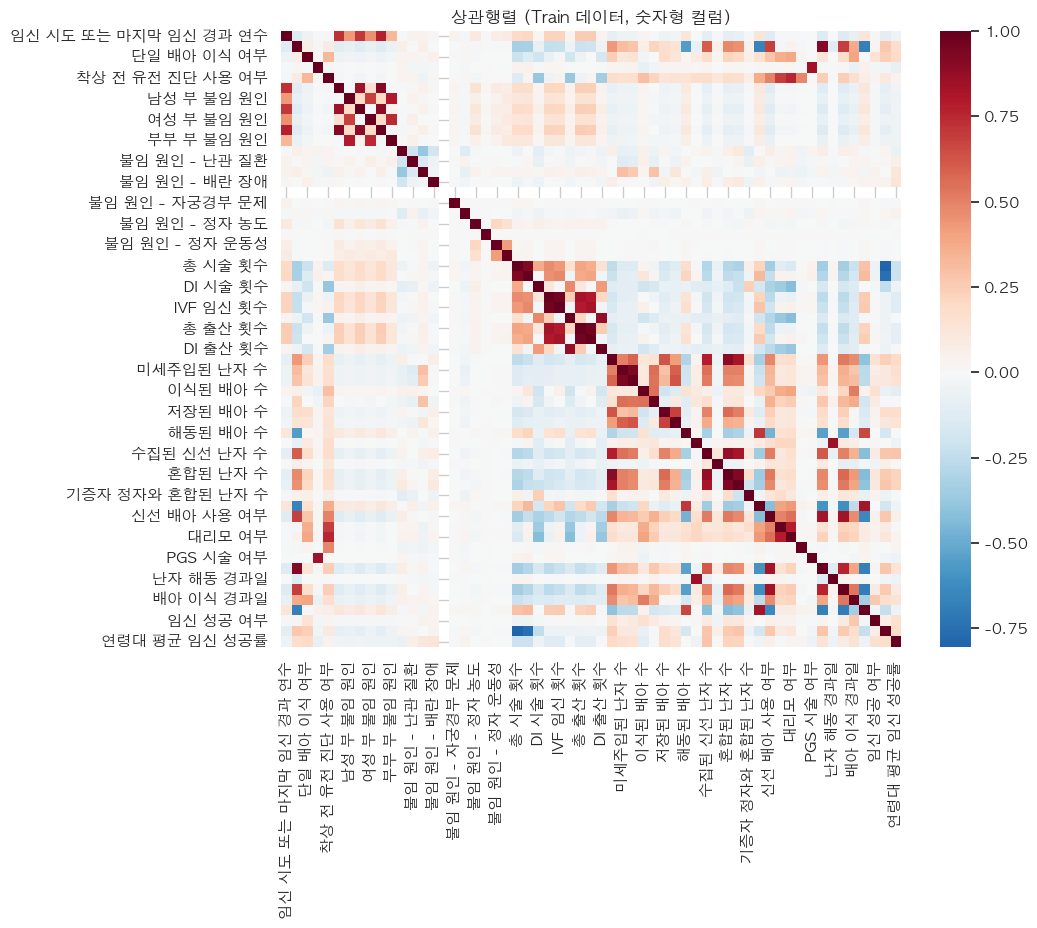

Target correlation:
 임신 성공 여부                 1.000000
배아 이식 경과일                0.273033
이식된 배아 수                 0.161080
연령대 평균 임신 성공률            0.156245
총 생성 배아 수                0.151343
단일 배아 이식 여부              0.139127
혼합된 난자 수                 0.122375
파트너 정자와 혼합된 난자 수         0.111067
미세주입에서 생성된 배아 수          0.095394
수집된 신선 난자 수              0.090067
미세주입 배아 이식 수             0.084145
난자 혼합 경과일                0.077475
미세주입된 난자 수               0.075507
임신 시도 대비 성공률             0.072028
총 시술 횟수                  0.058923
IVF 시술 횟수                0.055852
신선 배아 사용 여부              0.053753
기증 배아 사용 여부              0.047636
대리모 여부                   0.044899
저장된 배아 수                 0.041753
저장된 신선 난자 수              0.039628
불임 원인 - 남성 요인            0.037908
배란 자극 여부                 0.033212
기증자 정자와 혼합된 난자 수         0.030317
배아 해동 경과일                0.029557
착상 전 유전 진단 사용 여부         0.027970
미세주입 후 저장된 배아 수          0.027729
착상 전 유전 검사 사용 여부         0.026033
불임 원인 - 배란 장애            0.

In [ ]:
# %% [Cell 3.5] - 상관분석 & 저영향 변수 제거 + 한글 폰트 설정

import matplotlib as mpl

# 1) 한글 폰트 설정 (Windows 기준: 'Malgun Gothic')
#    Mac은 'AppleGothic', 리눅스는 'NanumGothic' 등을 사용
mpl.rc('font', family='AppleGothic')
mpl.rc('axes', unicode_minus=False)

num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col not in num_cols:
    # 타겟을 수치형으로
    train_df[target_col] = pd.to_numeric(train_df[target_col], errors='coerce')
    num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = train_df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="RdBu_r", center=0)
plt.title("상관행렬 (Train 데이터, 숫자형 컬럼)")
plt.show()

if target_col in corr_matrix.columns:
    corr_with_target = corr_matrix[target_col].abs().sort_values(ascending=False)
    print("Target correlation:\n", corr_with_target)

    low_corr_thresh = 0.02
    low_corr_vars = corr_with_target[corr_with_target<low_corr_thresh].index.tolist()
    print(f"Removing {len(low_corr_vars)} features (|corr| < {low_corr_thresh}):", low_corr_vars)

    drop_cols = [c for c in low_corr_vars if c!=target_col]
    train_df.drop(columns=drop_cols, inplace=True, errors='ignore')

    # test_df에서도 동일 컬럼 drop
    test_df.drop(columns=drop_cols, inplace=True, errors='ignore')
else:
    print("Target not in correlation matrix. Skipping...")

print("After correlation-based removal, train shape:", train_df.shape)
print("After correlation-based removal, test shape :", test_df.shape)


# Cell 4: 인코딩(Ordinal, One-Hot)

In [ ]:
# %% [Cell 4] - One-Hot 인코딩

# 1) 문자열 열 확인
obj_cols_train = train_df.select_dtypes(include=['object']).columns.tolist()
obj_cols_test  = test_df.select_dtypes(include=['object']).columns.tolist()
print("Train 문자열 열:", obj_cols_train)
print("Test  문자열 열:", obj_cols_test)

# 2) 인코딩 대상 열 (예: "시술 유형_원본" 등)
to_encode = ["시술 유형_원본"]  # 실제 인코딩할 문자열 열
# 만약 다른 문자열 열도 필요하면 추가

# 3) 그 외 문자열 열은 drop(예시)
to_drop_train = [c for c in obj_cols_train if c not in to_encode]
to_drop_test  = [c for c in obj_cols_test  if c not in to_encode]

train_df.drop(columns=to_drop_train, inplace=True, errors='ignore')
test_df.drop(columns=to_drop_test,   inplace=True, errors='ignore')

# 4) One-Hot 인코딩
if any(col in train_df.columns for col in to_encode):
    train_df = pd.get_dummies(train_df, columns=to_encode, drop_first=False)
    test_df  = pd.get_dummies(test_df,  columns=to_encode, drop_first=False)

# 5) Train/Test 컬럼 동기화
train_cols = set(train_df.columns)
test_cols  = set(test_df.columns)
common_cols = list(train_cols.intersection(test_cols))

# Target은 Train에만 존재하므로 제외
if target_col in common_cols:
    common_cols.remove(target_col)

# Train: [target_col] + sorted(common_cols)
train_df = train_df[[target_col] + sorted(common_cols)]
test_df  = test_df[sorted(common_cols)]

print("After One-Hot, train shape:", train_df.shape)
print("After One-Hot, test shape :", test_df.shape)

# 문자열 열이 남았는지 최종 확인
obj_cols_train2 = train_df.select_dtypes(include=['object']).columns
obj_cols_test2  = test_df.select_dtypes(include=['object']).columns
print("인코딩 후 남은 문자열 열 (train):", obj_cols_train2)
print("인코딩 후 남은 문자열 열 (test) :", obj_cols_test2)


Train 문자열 열: ['시술 시기 코드', '시술 당시 나이', '시술 유형', '특정 시술 유형', '배란 유도 유형', '배아 생성 주요 이유', '클리닉 내 총 시술 횟수', '난자 출처', '정자 출처', '난자 기증자 나이', '정자 기증자 나이', '시술 유형_원본']
Test  문자열 열: ['시술 시기 코드', '시술 당시 나이', '시술 유형', '특정 시술 유형', '배란 유도 유형', '배아 생성 주요 이유', '클리닉 내 총 시술 횟수', '난자 출처', '정자 출처', '난자 기증자 나이', '정자 기증자 나이', '시술 유형_원본']
After One-Hot, train shape: (256351, 34)
After One-Hot, test shape : (90067, 33)
인코딩 후 남은 문자열 열 (train): Index([], dtype='object')
인코딩 후 남은 문자열 열 (test) : Index([], dtype='object')


# Cell 5: GAIN Imputation 정의(GAN)

In [ ]:
# %% [Cell 5] - GAIN Imputation 정의 (기존)

class Generator(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256,256], dropout_rate=0.2):
        super(Generator, self).__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, input_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256,256], dropout_rate=0.2):
        super(Discriminator, self).__init__()
        combined_dim = input_dim*2
        layers = []
        prev_dim = combined_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, input_dim))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)
    def forward(self, x, h):
        inp = torch.cat([x,h], dim=1)
        return self.net(inp)

def gain_impute(data_x,
                batch_size=256,
                hint_rate=0.9,
                alpha=100,
                iterations=5000,
                hidden_dims=[256,256],
                dropout_rate=0.2,
                learning_rate=1e-3,
                device=None):
    if device is None:
        device = torch.device('cpu')
    X = data_x.copy()
    n, d = X.shape
    # -1 => 결측치로 간주
    M = (~np.isclose(X, -1.0)).astype(float)
    X_filled = np.where(np.isclose(X, -1.0), np.random.uniform(0,0.01,size=X.shape), X)

    X_tensor = torch.tensor(X_filled, dtype=torch.float32, device=device)
    M_tensor = torch.tensor(M,       dtype=torch.float32, device=device)

    G = Generator(d, hidden_dims, dropout_rate).to(device)
    D = Discriminator(d, hidden_dims, dropout_rate).to(device)

    G_opt = optim.Adam(G.parameters(), lr=learning_rate)
    D_opt = optim.Adam(D.parameters(), lr=learning_rate)

    bce_loss = nn.BCELoss()
    mse_loss = nn.MSELoss()

    for it in range(iterations):
        batch_idx = np.random.choice(n, batch_size, replace=True)
        X_mb = X_tensor[batch_idx]
        M_mb = M_tensor[batch_idx]
        Z_mb = torch.rand_like(X_mb)
        one_minus_M_mb = 1. - M_mb

        X_mb_input = M_mb*X_mb + one_minus_M_mb*Z_mb
        G_sample = G(X_mb_input)
        X_hat = M_mb*X_mb + one_minus_M_mb*G_sample

        H_mb = (torch.rand(M_mb.shape, device=device)<hint_rate).float()*M_mb

        # Discriminator
        D_prob = D(X_hat, H_mb)
        D_loss = bce_loss(D_prob, M_mb)
        D_opt.zero_grad()
        D_loss.backward(retain_graph=True)
        D_opt.step()

        # Generator
        D_prob_for_G = D(X_hat, H_mb)
        G_loss_adv = bce_loss(D_prob_for_G, 1.-M_mb)
        G_loss_rec = mse_loss(M_mb*X_hat, M_mb*X_mb)
        G_loss = G_loss_adv + alpha*G_loss_rec

        G_opt.zero_grad()
        G_loss.backward()
        G_opt.step()

        if (it+1)%500==0:
            print(f"[GAIN] Iter {it+1}/{iterations} | D_loss={D_loss.item():.4f}, G_loss={G_loss.item():.4f}")

    # 최종 imputation
    Z_full = torch.rand_like(X_tensor)
    one_minus_M = 1. - M_tensor
    X_input = M_tensor*X_tensor + one_minus_M*Z_full
    G_output = G(X_input)
    X_imputed = M_tensor*X_tensor + one_minus_M*G_output
    return X_imputed.detach().cpu().numpy()


# Cell 6: GAIN Imputation 적용

In [ ]:
# %% [Cell 6]

# 이제 train_df, test_df에는 전부 숫자형 컬럼만 존재해야 함.
train_arr = train_df.values.astype(np.float32)
test_arr  = test_df.values.astype(np.float32)

print("Applying GAIN Imputation with device:", device)
train_imputed_arr = gain_impute(
    train_arr,
    batch_size=256,
    hint_rate=0.9,
    alpha=100,
    iterations=3000,  # 필요 시 5000 등 조절
    hidden_dims=[256,256],
    dropout_rate=0.2,
    learning_rate=1e-3,
    device=device
)
test_imputed_arr = gain_impute(
    test_arr,
    batch_size=256,
    hint_rate=0.9,
    alpha=100,
    iterations=3000,
    hidden_dims=[256,256],
    dropout_rate=0.2,
    learning_rate=1e-3,
    device=device
)

train_df_imputed = pd.DataFrame(train_imputed_arr, columns=train_df.columns)
test_df_imputed  = pd.DataFrame(test_imputed_arr,  columns=test_df.columns)

print("train_df_imputed shape:", train_df_imputed.shape)
print("test_df_imputed shape :", test_df_imputed.shape)


Applying GAIN Imputation with device: mps
[GAIN] Iter 500/3000 | D_loss=0.0113, G_loss=6.4190
[GAIN] Iter 1000/3000 | D_loss=0.0059, G_loss=7.7229
[GAIN] Iter 1500/3000 | D_loss=0.0123, G_loss=8.8667
[GAIN] Iter 2000/3000 | D_loss=0.0084, G_loss=9.3160
[GAIN] Iter 2500/3000 | D_loss=0.0101, G_loss=10.5291
[GAIN] Iter 3000/3000 | D_loss=0.0097, G_loss=11.9287
[GAIN] Iter 500/3000 | D_loss=0.0144, G_loss=6.8522
[GAIN] Iter 1000/3000 | D_loss=0.0065, G_loss=7.4268
[GAIN] Iter 1500/3000 | D_loss=0.0099, G_loss=8.7983
[GAIN] Iter 2000/3000 | D_loss=0.0080, G_loss=9.1149
[GAIN] Iter 2500/3000 | D_loss=0.0096, G_loss=8.4482
[GAIN] Iter 3000/3000 | D_loss=0.0089, G_loss=9.4178
train_df_imputed shape: (256351, 34)
test_df_imputed shape : (90067, 33)


# Cell 7: 데이터 분할 + SMOTE & RepeatedStratifiedKFold 준비

In [ ]:
# %% [Cell 7]

target_col = "임신 성공 여부"
X_all = train_df_imputed.drop(columns=[target_col])
y_all = train_df_imputed[target_col]

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print("Train shape:", X_train.shape, "Val shape:", X_val.shape)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("After SMOTE:", X_train_sm.shape, np.bincount(y_train_sm.astype(int)))

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
print("rskf =", rskf)



Train shape: (205080, 33) Val shape: (51271, 33)
After SMOTE: (304196, 33) [152098 152098]
rskf = RepeatedStratifiedKFold(n_repeats=2, n_splits=5, random_state=42)


# Cell 8: Optuna로 (XGB, LGB, RF, CatBoost, TabTransformer) 튜닝

In [ ]:
# %% [Cell 8] - Optuna Tuning: XGB, LGB, RF, CatBoost, TabTransformer

import optuna
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from skorch import NeuralNetClassifier

# 추가 라이브러리
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.ensemble import RandomForestClassifier

############################################
# (A) MPS/CPU 설정 (선택)
############################################
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS device is available. Using MPS!")
else:
    device = torch.device("cpu")
    print("MPS device is not available. Using CPU.")


############################################
# (B) XGBoost 튜닝
############################################
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.1)
    }
    xgb_model = xgb.XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        **params
    )
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', xgb_model)
    ])
    scores = cross_val_score(pipe, X_train_sm, y_train_sm, cv=rskf,
                             scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)
best_params_xgb = study_xgb.best_params
best_value_xgb  = study_xgb.best_value
print("\n=== XGBoost ===")
print("Best params:", best_params_xgb)
print("Best value :", best_value_xgb)


############################################
# (C) LightGBM 튜닝
############################################
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 2, 64),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.1)
    }
    lgb_model = lgb.LGBMClassifier(random_state=42, **params)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lgb', lgb_model)
    ])
    scores = cross_val_score(pipe, X_train_sm, y_train_sm, cv=rskf,
                             scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=20, show_progress_bar=True)
best_params_lgb = study_lgb.best_params
best_value_lgb  = study_lgb.best_value
print("\n=== LightGBM ===")
print("Best params:", best_params_lgb)
print("Best value :", best_value_lgb)


############################################
# (D) RandomForest 튜닝
############################################
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10, step=2),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'bootstrap': trial.suggest_categorical('bootstrap',[True,False])
    }
    rf_model = RandomForestClassifier(random_state=42, **params)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('rf', rf_model)
    ])
    scores = cross_val_score(pipe, X_train_sm, y_train_sm, cv=rskf,
                             scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)
best_params_rf = study_rf.best_params
best_value_rf  = study_rf.best_value
print("\n=== RandomForest ===")
print("Best params:", best_params_rf)
print("Best value :", best_value_rf)


############################################
# (E) CatBoost 튜닝
############################################
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 600, step=200),
        'depth': trial.suggest_int('depth',4,10),
        'learning_rate': trial.suggest_float('learning_rate',1e-3,0.3,log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg',1e-4,10.0,log=True),
        'random_strength': trial.suggest_float('random_strength',1e-4,10.0,log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature',0,10)
    }
    cat_model = cb.CatBoostClassifier(random_state=42, verbose=0, **params)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('cat', cat_model)
    ])
    scores = cross_val_score(pipe, X_train_sm, y_train_sm, cv=rskf,
                             scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=20, show_progress_bar=True)
best_params_cat = study_cat.best_params
best_value_cat  = study_cat.best_value
print("\n=== CatBoost ===")
print("Best params:", best_params_cat)
print("Best value :", best_value_cat)


############################################
# (F) TabTransformer 튜닝
############################################
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim, dropout=0.1):
        super(TransformerBlock, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_hidden_dim, embed_dim)
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = x + self.dropout1(attn_out)
        x = self.norm1(x)
        ff_out = self.ff(x)
        x = x + self.dropout2(ff_out)
        x = self.norm2(x)
        return x

class TabTransformer(nn.Module):
    def __init__(self,
                 num_features,
                 embed_dim=32,
                 num_heads=4,
                 num_layers=2,
                 ff_hidden_dim=64,
                 dropout=0.1,
                 num_classes=2,
                 use_cls_token=True):
        super(TabTransformer, self).__init__()
        self.num_features = num_features
        self.embed_dim = embed_dim
        self.use_cls_token = use_cls_token

        self.feature_embeds = nn.ModuleList(
            [nn.Linear(1, embed_dim) for _ in range(num_features)]
        )
        if use_cls_token:
            self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim))
            self.num_tokens = num_features + 1
        else:
            self.cls_token = None
            self.num_tokens = num_features

        self.pos_embed = nn.Parameter(torch.randn(1,self.num_tokens,embed_dim))

        self.transformer_layers = nn.ModuleList(
            [TransformerBlock(embed_dim, num_heads, ff_hidden_dim, dropout)
             for _ in range(num_layers)]
        )

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_hidden_dim, num_classes)
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = x.unsqueeze(-1)
        emb_list = []
        for i, fe in enumerate(self.feature_embeds):
            feat_i = x[:, i, :]
            emb_i  = fe(feat_i)
            emb_list.append(emb_i)
        x_emb = torch.stack(emb_list, dim=1)
        if self.use_cls_token:
            cls_tok = self.cls_token.expand(batch_size, -1, -1)
            x_emb = torch.cat([cls_tok, x_emb], dim=1)

        x_emb = x_emb + self.pos_embed
        x_trans = x_emb.transpose(0,1)
        for layer in self.transformer_layers:
            x_trans = layer(x_trans)
        x_trans = x_trans.transpose(0,1)

        if self.use_cls_token:
            out = x_trans[:, 0, :]
        else:
            out = x_trans.mean(dim=1)
        logits = self.mlp_head(out)
        return logits

# (embed_dim, num_heads) 배수 조합 확장
combos = [
    (16,1),(16,2),(16,4),(16,8),
    (24,1),(24,2),(24,3),(24,4),(24,6),(24,8),
    (32,1),(32,2),(32,4),(32,8),
    (40,1),(40,2),(40,4),(40,5),(40,8),
    (48,1),(48,2),(48,3),(48,4),(48,6),(48,8),
    (56,1),(56,2),(56,4),(56,7),(56,8),
    (64,1),(64,2),(64,4),(64,8),
]

def objective_tab(trial):
    combo = trial.suggest_categorical('combo', combos)
    embed_dim, num_heads = combo

    ff_hidden_dim = trial.suggest_int('ff_hidden_dim', 32, 128, step=32)
    dropout       = trial.suggest_float('dropout', 0.0, 0.3, step=0.1)
    lr            = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    max_epochs    = trial.suggest_int('max_epochs', 10, 30, step=10)
    num_layers    = trial.suggest_int('num_layers', 1, 3)

    net = NeuralNetClassifier(
        module=TabTransformer,
        module__num_features=X_train_sm.shape[1],
        module__embed_dim=embed_dim,
        module__num_heads=num_heads,
        module__num_layers=num_layers,
        module__ff_hidden_dim=ff_hidden_dim,
        module__dropout=dropout,
        module__num_classes=2,
        module__use_cls_token=True,

        max_epochs=max_epochs,
        lr=lr,
        optimizer=optim.Adam,
        criterion=nn.CrossEntropyLoss,
        batch_size=64,
        iterator_train__shuffle=True,
        device=device,
        verbose=0
    )

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('tab', net)
    ])

    scores = cross_val_score(
        pipe,
        X_train_sm, y_train_sm,
        cv=rskf,
        scoring='roc_auc',
        n_jobs=-1
    )
    return scores.mean()

study_tab = optuna.create_study(direction='maximize')
study_tab.optimize(objective_tab, n_trials=10, show_progress_bar=True)
best_params_tab = study_tab.best_params
best_value_tab  = study_tab.best_value
print("\n=== TabTransformer ===")
print("Best params:", best_params_tab)
print("Best value :", best_value_tab)

print("\n==== ALL TUNING DONE ====")

[I 2025-02-18 10:49:53,132] A new study created in memory with name: no-name-c7fc1b80-cb8b-43ce-bb74-5848c6c2a8a4


MPS device is available. Using MPS!


  0%|          | 0/20 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [10:49:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [10:49:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [10:49:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [10:49:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.11/site-packa

[I 2025-02-18 10:50:08,878] Trial 0 finished with value: 0.9120152885142471 and parameters: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.23374191002817762, 'subsample': 0.9, 'colsample_bytree': 0.8}. Best is trial 0 with value: 0.9120152885142471.


...

[I 2025-02-18 12:45:38,688] Trial 15 finished with value: 0.9062490789951637 and parameters: {'iterations': 400, 'depth': 10, 'learning_rate': 0.11773645418673064, 'l2_leaf_reg': 0.00011365835775965091, 'random_strength': 0.08086410798210844, 'bagging_temperature': 4.566037803951891}. Best is trial 6 with value: 0.9138916827388804.
[I 2025-02-18 12:48:16,853] Trial 16 finished with value: 0.9071842370384777 and parameters: {'iterations': 600, 'depth': 9, 'learning_rate': 0.010852472491990948, 'l2_leaf_reg': 0.07668259540262048, 'random_strength': 0.004010489669546994, 'bagging_temperature': 2.3790034483801965}. Best is trial 6 with value: 0.9138916827388804.
[I 2025-02-18 12:48:51,579] Trial 17 finished with value: 0.8995999527393923 and parameters: {'iterations': 200, 'depth': 6, 'learning_rate': 0.04379171434770653, 'l2_leaf_reg': 1.397494835309615, 'random_strength': 3.0404625611600267, 'bagging_temperature': 8.113302618676851}. Best is trial 6 with value: 0.9138916827388804.
[I 202

[I 2025-02-18 12:54:44,757] A new study created in memory with name: no-name-aa090807-8c20-4a62-bff0-d076f9e246dd


[I 2025-02-18 12:54:44,733] Trial 19 finished with value: 0.8973945385954144 and parameters: {'iterations': 600, 'depth': 10, 'learning_rate': 0.013037063035466276, 'l2_leaf_reg': 0.12039888966001017, 'random_strength': 9.550348168546213, 'bagging_temperature': 9.860585063403503}. Best is trial 6 with value: 0.9138916827388804.

=== CatBoost ===
Best params: {'iterations': 600, 'depth': 9, 'learning_rate': 0.04297242013917933, 'l2_leaf_reg': 0.017259931071831748, 'random_strength': 0.6881088253547414, 'bagging_temperature': 6.305574888058219}
Best value : 0.9138916827388804


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-02-18 14:26:56,356] Trial 0 finished with value: 0.6973273374911051 and parameters: {'combo': (24, 1), 'ff_hidden_dim': 32, 'dropout': 0.3, 'lr': 0.0005666685252921112, 'max_epochs': 20, 'num_layers': 1}. Best is trial 0 with value: 0.6973273374911051.
[I 2025-02-18 15:32:30,810] Trial 1 finished with value: 0.7360811022285689 and parameters: {'combo': (24, 1), 'ff_hidden_dim': 64, 'dropout': 0.2, 'lr': 0.0027415125418440143, 'max_epochs': 10, 'num_layers': 2}. Best is trial 1 with value: 0.7360811022285689.
[I 2025-02-18 16:38:14,231] Trial 2 finished with value: 0.8366115795050995 and parameters: {'combo': (16, 1), 'ff_hidden_dim': 32, 'dropout': 0.0, 'lr': 0.0012955603814672862, 'max_epochs': 10, 'num_layers': 3}. Best is trial 2 with value: 0.8366115795050995.
[I 2025-02-18 21:24:43,718] Trial 3 finished with value: 0.82280982473669 and parameters: {'combo': (40, 2), 'ff_hidden_dim': 128, 'dropout': 0.2, 'lr': 0.0013331294112611252, 'max_epochs': 20, 'num_layers': 3}. Best 

# Cell 9: Stacking 앙상블 + Weighted Ensemble

In [ ]:
# %% [Cell 9] - Stacking 앙상블 & Weighted Ensemble

##################################
# 1) 스태킹 앙상블 (Stacking)
##################################

# (1) 최적 파라미터 기반 모델 생성
#    - XGB, LGB, RF, CatBoost은 Optuna 결과로부터 best_params
#    - TabTransformer도 마찬가지로 best_params_tab

# 1-1) XGB
xgb_final = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    **best_params_xgb
)

# 1-2) LightGBM
lgb_final = lgb.LGBMClassifier(
    random_state=42,
    **best_params_lgb
)

# 1-3) RandomForest
rf_final = RandomForestClassifier(
    random_state=42,
    **best_params_rf
)

# 1-4) CatBoost
cat_final = cb.CatBoostClassifier(
    random_state=42,
    verbose=0,  # Optuna 탐색 시 verbose=0
    **best_params_cat
)

# 1-5) TabTransformer (skorch)
#     - 아래는 예시: skorch wrapper (Cell 8에서 정의한 TabTransformer class & best_params_tab)
from torch.optim import Adam
import torch.nn as nn

class TransformerBlock(nn.Module):
    """
    스택킹에 사용할 TabTransformer의 내부 Block.
    """
    def __init__(self, embed_dim, num_heads, ff_hidden_dim, dropout=0.1):
        super(TransformerBlock, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_hidden_dim, embed_dim)
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout2 = nn.Dropout(dropout)
    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = x + self.dropout1(attn_out)
        x = self.norm1(x)
        ff_out = self.ff(x)
        x = x + self.dropout2(ff_out)
        x = self.norm2(x)
        return x

class TabTransformer(nn.Module):
    """
    Tabular data용 Transformer 모델.
    """
    def __init__(self,
                 num_features,
                 embed_dim=32,
                 num_heads=4,
                 num_layers=2,
                 ff_hidden_dim=64,
                 dropout=0.1,
                 num_classes=2,
                 use_cls_token=True):
        super(TabTransformer, self).__init__()
        self.num_features = num_features
        self.embed_dim = embed_dim
        self.use_cls_token = use_cls_token

        # 각 feature마다 임베딩
        self.feature_embeds = nn.ModuleList(
            [nn.Linear(1, embed_dim) for _ in range(num_features)]
        )
        if use_cls_token:
            self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim))
            self.num_tokens = num_features+1
        else:
            self.cls_token = None
            self.num_tokens = num_features

        self.pos_embed = nn.Parameter(torch.randn(1,self.num_tokens,embed_dim))

        # TransformerBlock 스택
        self.transformer_layers = nn.ModuleList(
            [
                TransformerBlock(
                    embed_dim,
                    num_heads,
                    ff_hidden_dim,
                    dropout
                ) for _ in range(num_layers)
            ]
        )

        # 최종 MLP
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_hidden_dim, num_classes)
        )

    def forward(self, x):
        batch_size = x.size(0)
        # (batch_size, num_features) -> (batch_size, num_features, 1)
        x = x.unsqueeze(-1)
        emb_list = []
        for i, fe_layer in enumerate(self.feature_embeds):
            feat_i = x[:,i,:]  # (batch_size,1)
            emb_i = fe_layer(feat_i)  # (batch_size, embed_dim)
            emb_list.append(emb_i)
        x_emb = torch.stack(emb_list, dim=1)  # (batch_size, num_features, embed_dim)

        # cls token
        if self.use_cls_token:
            cls_tok = self.cls_token.expand(batch_size,-1,-1)  # (batch_size,1,embed_dim)
            x_emb = torch.cat([cls_tok, x_emb], dim=1)         # (batch_size,num_features+1,embed_dim)

        # 위치 임베딩
        x_emb = x_emb + self.pos_embed

        # Transformer 입력: (seq_len,batch_size,embed_dim)
        x_trans = x_emb.transpose(0,1)
        for layer in self.transformer_layers:
            x_trans = layer(x_trans)
        x_trans = x_trans.transpose(0,1)

        # cls_token 사용 -> 첫 번째 토큰, 아니면 mean
        if self.use_cls_token:
            out = x_trans[:,0,:]  # (batch_size, embed_dim)
        else:
            out = x_trans.mean(dim=1)

        # MLP
        logits = self.mlp_head(out)
        return logits

from skorch import NeuralNetClassifier
num_feats = X_train_sm.shape[1]
final_tab = NeuralNetClassifier(
    module=TabTransformer,
    module__num_features=num_feats,
    module__embed_dim=best_params_tab['embed_dim'],
    module__num_heads=best_params_tab['num_heads'],
    module__num_layers=best_params_tab['num_layers'],
    module__ff_hidden_dim=best_params_tab['ff_hidden_dim'],
    module__dropout=best_params_tab['dropout'],
    module__num_classes=2,
    module__use_cls_token=True,
    max_epochs=best_params_tab['max_epochs'],
    lr=best_params_tab['lr'],
    optimizer=Adam,
    criterion=nn.CrossEntropyLoss,
    batch_size=64,
    iterator_train__shuffle=True,
    device=device,
    verbose=0
)

# 2) 스택킹 베이스 모델
base_estimators = [
    ('xgb', xgb_final),
    ('lgb', lgb_final),
    ('rf' , rf_final),
    ('cat', cat_final),
    # TabTransformer를 sklearn의 StackingClassifier에 직접 넣으려면 별도 wrapping 필요
    # skorch 모델은 n_jobs 병렬처리 시 이슈가 있을 수 있으니 주의
    # 여기서는 예시로 4개 모델만 stacking
]

# 3) 메타 모델
meta_model = LogisticRegression(solver='liblinear', random_state=42)

# 4) StackingClassifier
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1,
    passthrough=False
)

# 5) Stacking fit
stacking_clf.fit(X_train_sm, y_train_sm)

# 6) Validation 예측 (stack)
val_pred_proba_stack = stacking_clf.predict_proba(X_val)[:,1]
val_auc_stack = roc_auc_score(y_val, val_pred_proba_stack)
print(f"[Stacking] Validation AUC: {val_auc_stack:.4f}")


##################################
# 2) Weighted Ensemble (Optuna)
##################################

# (a) 먼저 XGB, LGB, RF, CatBoost 모델을 X_train_sm, y_train_sm로 fit
#     (주의) 만약 stacking_clf.fit()만 했다면, base_estimators가 내부 cv로만 학습됨.
#     Weighted Ensemble은 개별 모델이 fully-trained 되어야 하므로, 별도 fit 필요.

xgb_final.fit(X_train_sm, y_train_sm)
lgb_final.fit(X_train_sm, y_train_sm)
rf_final.fit(X_train_sm,  y_train_sm)
cat_final.fit(X_train_sm, y_train_sm)

# (b) Validation 세트 확률
val_pred_proba_xgb = xgb_final.predict_proba(X_val)[:,1]
val_pred_proba_lgb = lgb_final.predict_proba(X_val)[:,1]
val_pred_proba_rf  = rf_final.predict_proba(X_val)[:,1]
val_pred_proba_cat = cat_final.predict_proba(X_val)[:,1]

def objective_weighted(trial):
    w_xgb = trial.suggest_float('w_xgb',0.0,1.0)
    w_lgb = trial.suggest_float('w_lgb',0.0,1.0)
    w_rf  = trial.suggest_float('w_rf', 0.0,1.0)
    w_cat = trial.suggest_float('w_cat',0.0,1.0)
    sum_w = w_xgb + w_lgb + w_rf + w_cat
    if sum_w<1e-9:
        return 0.0
    w_xgb/=sum_w
    w_lgb/=sum_w
    w_rf /=sum_w
    w_cat/=sum_w

    ensemble_proba = (
        w_xgb*val_pred_proba_xgb +
        w_lgb*val_pred_proba_lgb +
        w_rf *val_pred_proba_rf  +
        w_cat*val_pred_proba_cat
    )
    return roc_auc_score(y_val, ensemble_proba)

study_w = optuna.create_study(direction='maximize')
study_w.optimize(objective_weighted, n_trials=30, show_progress_bar=True)
best_w = study_w.best_params
print("Best Weighted Ensemble params:", best_w)

# Weighted Ensemble 결과
best_wx = best_w['w_xgb']
best_wl = best_w['w_lgb']
best_wr = best_w['w_rf']
best_wc = best_w['w_cat']
sum_w = best_wx + best_wl + best_wr + best_wc
if sum_w<1e-9:
    sum_w=1e-9

best_wx/=sum_w
best_wl/=sum_w
best_wr/=sum_w
best_wc/=sum_w

val_ens_proba = (
    best_wx*val_pred_proba_xgb +
    best_wl*val_pred_proba_lgb +
    best_wr*val_pred_proba_rf  +
    best_wc*val_pred_proba_cat
)
val_auc_ens = roc_auc_score(y_val, val_ens_proba)
print(f"[Weighted Ensemble] Validation AUC: {val_auc_ens:.4f}")


# Cell 10: 최적 임계값(F1), Learning Curve, Test 예측 & 제출

In [ ]:
# %% [Cell 10] - 최적 임계값(F1), Learning Curve, Test 예측 & 제출

########################
# 1) 스태킹 최적 임계값
########################

# (1) 스택킹 예측값: val_pred_proba_stack
# (2) F1 최적화
precision_s, recall_s, thresholds_s = precision_recall_curve(y_val, val_pred_proba_stack)
f1_s = 2*(precision_s*recall_s)/(precision_s+recall_s+1e-8)
best_idx_s = f1_s.argmax()
best_thresh_s = thresholds_s[best_idx_s]
print(f"[Stacking] Best threshold for F1: {best_thresh_s:.4f}, F1={f1_s[best_idx_s]:.4f}")

val_pred_label_stack = (val_pred_proba_stack >= best_thresh_s).astype(int)
stack_auc = roc_auc_score(y_val, val_pred_proba_stack)
stack_f1  = f1_score(y_val, val_pred_label_stack)
print(f"[Stacking] AUC={stack_auc:.4f}, F1={stack_f1:.4f}")
print(classification_report(y_val, val_pred_label_stack))

cm_stack = confusion_matrix(y_val, val_pred_label_stack)
plt.figure(figsize=(5,4))
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Stacking + best F1 threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

########################
# 2) Weighted Ensemble 최적 임계값
########################

# (1) Weighted Ensemble 확률: val_ens_proba
precision_w, recall_w, thresholds_w = precision_recall_curve(y_val, val_ens_proba)
f1_w = 2*(precision_w*recall_w)/(precision_w+recall_w+1e-8)
best_idx_w = f1_w.argmax()
best_thresh_w = thresholds_w[best_idx_w]
print(f"[Weighted] Best threshold for F1: {best_thresh_w:.4f}, F1={f1_w[best_idx_w]:.4f}")

val_pred_label_w = (val_ens_proba >= best_thresh_w).astype(int)
w_auc = roc_auc_score(y_val, val_ens_proba)
w_f1  = f1_score(y_val, val_pred_label_w)
print(f"[Weighted] AUC={w_auc:.4f}, F1={w_f1:.4f}")
print(classification_report(y_val, val_pred_label_w))

cm_w = confusion_matrix(y_val, val_pred_label_w)
plt.figure(figsize=(5,4))
sns.heatmap(cm_w, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Weighted + best F1 threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

########################
# 3) Learning Curve (Stacking)
########################
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    stacking_clf,            # 스택킹 분류기
    X_train_sm, y_train_sm,  # SMOTE된 Train
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    train_sizes=np.linspace(0.1,1.0,5),
    shuffle=True,
    random_state=42
)
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Train AUC')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='r')
plt.plot(train_sizes, val_mean, 'o-', color='g', label='Val AUC')
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1, color='g')
plt.title("Learning Curve (Stacking Ensemble)")
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.legend(loc='best')
plt.grid()
plt.show()

########################
# 4) Test 예측 & 제출
########################

# (A) Stacking
test_proba_stack = stacking_clf.predict_proba(test_df_imputed)[:,1]
test_pred_stack  = (test_proba_stack >= best_thresh_s).astype(int)

submission_stack = pd.DataFrame({
    "ID": test_ids,
    "probability": test_proba_stack
})
submission_stack.to_csv("final_stacking_submission.csv", index=False)
print("Stacking submission: 'final_stacking_submission.csv' created!")

# (B) Weighted
#  - XGB, LGB, RF, CatBoost에 대해 test_df_imputed 예측
test_proba_xgb = xgb_final.predict_proba(test_df_imputed)[:,1]
test_proba_lgb = lgb_final.predict_proba(test_df_imputed)[:,1]
test_proba_rf  = rf_final.predict_proba(test_df_imputed)[:,1]
test_proba_cat = cat_final.predict_proba(test_df_imputed)[:,1]

test_ens_proba = (
    best_wx*test_proba_xgb +
    best_wl*test_proba_lgb +
    best_wr*test_proba_rf  +
    best_wc*test_proba_cat
)
test_pred_ens  = (test_ens_proba >= best_thresh_w).astype(int)

submission_w = pd.DataFrame({
    "ID": test_ids,
    "probability": test_ens_proba
})
submission_w.to_csv("final_weighted_submission.csv", index=False)
print("Weighted submission: 'final_weighted_submission.csv' created!")
